In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("../data/raw/ab_test_data.csv")

In [11]:
df.head()

,user_id,group,converted
0,1,control,0
1,2,control,1
2,3,control,0
3,4,control,0
4,5,control,0


In [12]:
df.shape

(10000, 3)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    10000 non-null  int64 
 1   group      10000 non-null  object
 2   converted  10000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 234.5+ KB


In [15]:
df.describe()

,user_id,converted
count,10000.00000,10000.000000
mean,5000.50000,0.104600
std,2886.89568,0.306053
min,1.00000,0.000000
25%,2500.75000,0.000000
50%,5000.50000,0.000000
75%,7500.25000,0.000000
max,10000.00000,1.000000


In [24]:
conversion_rates = df.groupby('group')['converted'].mean().reset_index()
conversion_rates.columns = ['group','conversion_rate']

C:\Users\zubiya shaikh\AppData\Local\Temp\ipykernel_20712\3411809408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = conversion_rates,x= 'group',y= 'conversion_rate', palette=['#d9534f', '#5cb85c'])


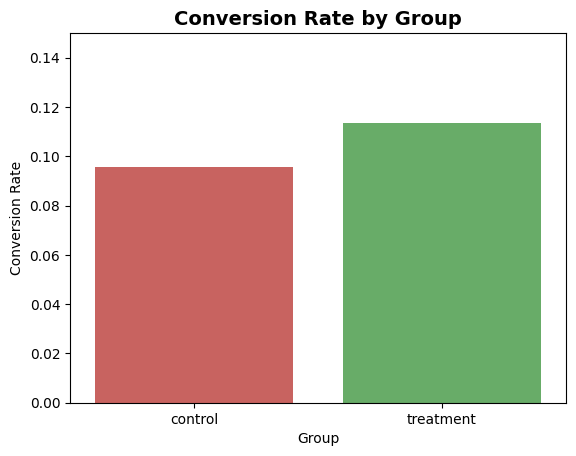

In [39]:
sns.barplot(data = conversion_rates,x= 'group',y= 'conversion_rate', palette=['#d9534f', '#5cb85c'])
plt.title('Conversion Rate by Group',fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate')
plt.xlabel('Group')
plt.ylim(0, 0.15)
plt.savefig('../reports/figures/conversion_rate_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

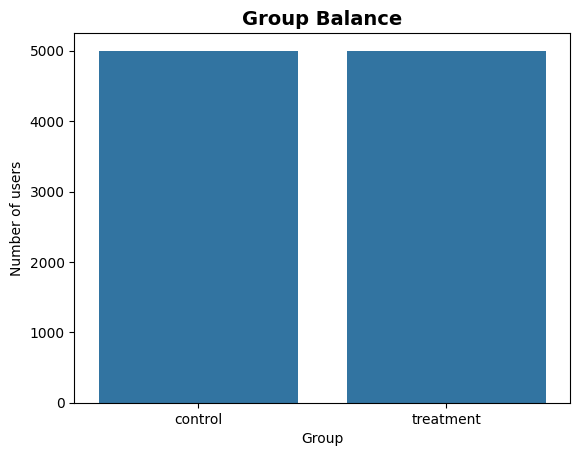

In [40]:
sns.countplot(data=df,x='group')
plt.title('Group Balance',fontsize = 14, fontweight='bold')
plt.xlabel('Group')
plt.ylabel('Number of users')
plt.savefig('../reports/figures/group_balance.png', dpi=150, bbox_inches='tight')
plt.show()

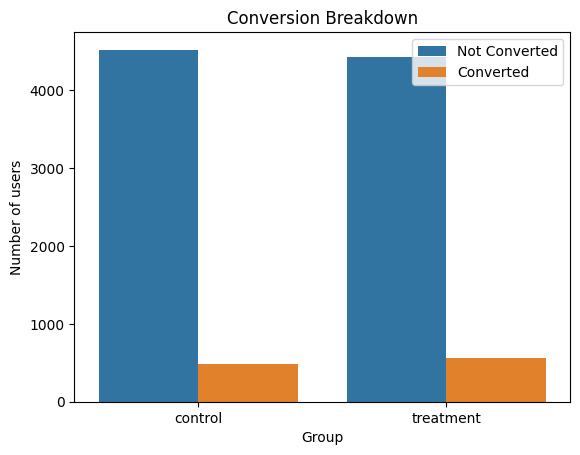

In [38]:
sns.countplot(data=df, x='group', hue='converted')
plt.title('Conversion Breakdown')
plt.xlabel('Group')
plt.ylabel('Number of users')
plt.legend(labels=['Not Converted', 'Converted'])
plt.savefig('../reports/figures/conversion_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()